# IRRM-CODEC: multi-chain inverse analysis

This notebook loads all saved inverse-model runs for the background-100k chains, rebuilds the test split, evaluates each best checkpoint, and summarizes length agreement, exact matches, and substitution errors across chains.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display

root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

CHAINS = ['igh', 'igk', 'igl', 'tra', 'trb', 'trd', 'trg']
SPLIT_SEED = 42
TRAIN_FRACTION = 0.8
VAL_FRACTION = 0.1
EVAL_BATCH_SIZE = 512

MODEL_ROOT_CANDIDATES = [
    Path('/projects/immunestatus/vdjrearm/irrmcodec/inverse_background_100k'),
    root / 'inverse_background_100k',
    root / 'artifacts' / 'inverse_background_100k',
]

AIRR_ROOT_CANDIDATES = [
    Path('/projects/immunestatus/vdjrearm/airr_format'),
    root / 'notebooks' / 'projects' / 'immunestatus' / 'vdjrearm' / 'airr_format',
]

EMBEDDINGS_ROOT_CANDIDATES = [
    Path('/projects/immunestatus/vdjrearm/tcremp'),
    root / 'notebooks' / 'projects' / 'immunestatus' / 'vdjrearm' / 'tcremp',
]

AA_ORDER = list('CSTAGPDEQNHRKMILVWYF')
AA_GROUPS = {
    'C': set('C'),
    'STAGP': set('STAGP'),
    'DEQN': set('DEQN'),
    'HRK': set('HRK'),
    'MILV': set('MILV'),
    'WYF': set('WYF'),
}
AA_TO_GROUP = {aa: group_name for group_name, aas in AA_GROUPS.items() for aa in aas}
GROUP_BOUNDARIES = np.cumsum([1, 5, 4, 3, 4])

def first_existing(paths):
    for path in paths:
        if path is not None and Path(path).exists():
            return Path(path)
    return None

def read_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

def embedding_candidates(chain, embeddings_root):
    return [
        embeddings_root / f'{chain}_background_100k_tcremp.parquet',
        embeddings_root / f'{chain}_background_100k_embeddings.parquet',
        embeddings_root / f'{chain}_background_100k.parquet',
    ]

model_root = first_existing(MODEL_ROOT_CANDIDATES) or MODEL_ROOT_CANDIDATES[0]
airr_root = first_existing(AIRR_ROOT_CANDIDATES) or AIRR_ROOT_CANDIDATES[0]
embeddings_root = first_existing(EMBEDDINGS_ROOT_CANDIDATES) or EMBEDDINGS_ROOT_CANDIDATES[0]

def resolve_chain_paths(chain):
    model_dir = model_root / chain
    stats = read_json(model_dir / 'data_stats.json') if (model_dir / 'data_stats.json').exists() else {}

    airr_candidates = []
    if stats.get('airr_path'):
        airr_candidates.append(Path(stats['airr_path']))
    airr_candidates.append(airr_root / f'{chain}_background_100k.tsv')

    emb_candidates = []
    if stats.get('embeddings_path'):
        emb_candidates.append(Path(stats['embeddings_path']))
    emb_candidates.extend(embedding_candidates(chain, embeddings_root))

    airr_path = first_existing(airr_candidates) or airr_candidates[0]
    embeddings_path = first_existing(emb_candidates) or emb_candidates[0]

    return {
        'chain': chain,
        'model_dir': model_dir,
        'history_path': model_dir / 'history.json',
        'test_metrics_path': model_dir / 'test_metrics.json',
        'data_stats_path': model_dir / 'data_stats.json',
        'checkpoint_path': model_dir / 'best.pt',
        'mean_path': model_dir / 'mean.npy',
        'std_path': model_dir / 'std.npy',
        'airr_path': airr_path,
        'embeddings_path': embeddings_path,
    }

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_colwidth', 120)

print('root           :', root)
print('model_root     :', model_root)
print('airr_root      :', airr_root)
print('embeddings_root:', embeddings_root)

root           : /home/evlasova/irrm-codec
model_root     : /projects/immunestatus/vdjrearm/irrmcodec/inverse_background_100k
airr_root      : /projects/immunestatus/vdjrearm/airr_format
embeddings_root: /projects/immunestatus/vdjrearm/tcremp


In [2]:
path_rows = []
for chain in CHAINS:
    paths = resolve_chain_paths(chain)
    path_rows.append({
        'chain': chain,
        'model_dir': str(paths['model_dir']),
        'model_dir_exists': paths['model_dir'].exists(),
        'history_exists': paths['history_path'].exists(),
        'checkpoint_exists': paths['checkpoint_path'].exists(),
        'airr_exists': paths['airr_path'].exists(),
        'embeddings_exists': paths['embeddings_path'].exists(),
    })

paths_df = pd.DataFrame(path_rows)
display(paths_df)

available_chains = paths_df.loc[
    paths_df[['history_exists', 'checkpoint_exists', 'airr_exists', 'embeddings_exists']].all(axis=1),
    'chain',
].tolist()

if not available_chains:
    raise FileNotFoundError(
        'No complete inverse-model chain configuration was found. Update the configuration cell so the notebook can see the model, AIRR, and parquet files.'
    )

print('Chains ready for evaluation:', ', '.join(available_chains))

,chain,model_dir,model_dir_exists,history_exists,checkpoint_exists,airr_exists,embeddings_exists
0,igh,/projects/immunestatus/vdjrearm/irrmcodec/inverse_background_100k/igh,True,True,True,True,True
1,igk,/projects/immunestatus/vdjrearm/irrmcodec/inverse_background_100k/igk,True,True,True,True,True
2,igl,/projects/immunestatus/vdjrearm/irrmcodec/inverse_background_100k/igl,True,True,True,True,True
3,tra,/projects/immunestatus/vdjrearm/irrmcodec/inverse_background_100k/tra,True,True,True,True,True
4,trb,/projects/immunestatus/vdjrearm/irrmcodec/inverse_background_100k/trb,True,True,True,True,True
5,trd,/projects/immunestatus/vdjrearm/irrmcodec/inverse_background_100k/trd,True,True,True,True,True
6,trg,/projects/immunestatus/vdjrearm/irrmcodec/inverse_background_100k/trg,True,True,True,True,True


Chains ready for evaluation: igh, igk, igl, tra, trb, trd, trg


In [3]:
from irrm_codec.dataio import load_airr_with_embeddings
from irrm_codec.tokenization import decode
from irrm_codec.train_inverse import build_dataloader, run_epoch
from irrm_codec.inverse_model import InverseModel
from irrm_codec.utils import apply_standardizer, choose_device, split_indices

def build_substitution_outputs(results_df):
    conf_mat = pd.DataFrame(0, index=AA_ORDER, columns=AA_ORDER, dtype=int)
    within_group_errors = 0
    between_group_errors = 0
    total_errors = 0

    df_sub = results_df[results_df['length_match']].copy()
    for target_seq, pred_seq in zip(df_sub['target'], df_sub['predicted']):
        if len(target_seq) != len(pred_seq):
            continue
        for t_aa, p_aa in zip(target_seq, pred_seq):
            if t_aa not in AA_ORDER or p_aa not in AA_ORDER:
                continue
            if t_aa == p_aa:
                continue
            conf_mat.loc[t_aa, p_aa] += 1
            total_errors += 1
            if AA_TO_GROUP[t_aa] == AA_TO_GROUP[p_aa]:
                within_group_errors += 1
            else:
                between_group_errors += 1

    summary = pd.DataFrame({
        'count': [within_group_errors, between_group_errors, total_errors],
        'fraction': [
            within_group_errors / total_errors if total_errors else np.nan,
            between_group_errors / total_errors if total_errors else np.nan,
            1.0 if total_errors else np.nan,
        ],
    }, index=['within_group', 'between_group', 'total'])
    return conf_mat, summary

def load_chain_result(chain):
    paths = resolve_chain_paths(chain)
    history = read_json(paths['history_path'])
    history_df = pd.json_normalize(history)
    saved_test_metrics = read_json(paths['test_metrics_path'])
    data_stats = read_json(paths['data_stats_path'])

    df, emb, merge_stats = load_airr_with_embeddings(
        airr_path=paths['airr_path'],
        embeddings_path=paths['embeddings_path'],
        locus=chain,
        clone_id_col=data_stats.get('clone_id_column', 'clone_id'),
    )

    train_idx, val_idx, test_idx = split_indices(
        len(df),
        train_fraction=TRAIN_FRACTION,
        val_fraction=VAL_FRACTION,
        seed=SPLIT_SEED,
    )

    test_df = df.iloc[test_idx].reset_index(drop=True)
    test_emb = apply_standardizer(
        emb[test_idx],
        np.load(paths['mean_path']),
        np.load(paths['std_path']),
    )

    device = choose_device()
    checkpoint = torch.load(paths['checkpoint_path'], map_location=device)
    extra = checkpoint.get('extra', {})
    model = InverseModel(
        embedding_dim=extra.get('embedding_dim', test_emb.shape[1]),
        max_len=extra.get('max_len', data_stats.get('max_len', 40)),
    ).to(device)
    model.load_state_dict(checkpoint['model_state'])
    model.eval()

    test_loader = build_dataloader(
        test_df,
        test_emb,
        batch_size=EVAL_BATCH_SIZE,
        max_len=model.max_len,
        shuffle=False,
        num_workers=0,
    )
    recomputed_test_metrics = run_epoch(
        model,
        test_loader,
        optimizer=None,
        device=device,
        stage='test',
        epoch=1,
        num_epochs=1,
        log_interval=0,
        show_progress=False,
    )

    all_predictions = []
    emb_tensor = torch.tensor(test_emb, dtype=torch.float32)
    with torch.no_grad():
        for start in range(0, len(emb_tensor), EVAL_BATCH_SIZE):
            batch = emb_tensor[start:start + EVAL_BATCH_SIZE].to(device)
            pred_tokens = model.generate(batch, max_len=model.max_len).cpu()
            all_predictions.append(pred_tokens)
    pred_tokens = torch.cat(all_predictions, dim=0)

    predicted_aligned = [decode(row.tolist()) for row in pred_tokens]
    predicted = [decode(row.tolist(), remove_gaps=True) for row in pred_tokens]
    results_df = pd.DataFrame({
        'chain': chain,
        'target': test_df['junction_aa'].tolist(),
        'predicted_aligned': predicted_aligned,
        'predicted': predicted,
    })
    results_df['target_length'] = results_df['target'].str.len()
    results_df['predicted_length'] = results_df['predicted'].str.len()
    results_df['exact_match'] = results_df['target'] == results_df['predicted']
    results_df['length_match'] = results_df['target_length'] == results_df['predicted_length']
    results_df['length_delta'] = results_df['predicted_length'] - results_df['target_length']

    length_counts = (
        results_df.groupby(['target_length', 'predicted_length']).size().rename('count').reset_index()
    )
    length_confusion = (
        length_counts.pivot(index='target_length', columns='predicted_length', values='count').fillna(0).astype(int)
    )
    substitution_matrix, substitution_summary = build_substitution_outputs(results_df)

    return {
        'chain': chain,
        'history_df': history_df,
        'saved_test_metrics': saved_test_metrics,
        'recomputed_test_metrics': recomputed_test_metrics,
        'data_stats': data_stats,
        'merge_stats': merge_stats,
        'results_df': results_df,
        'length_confusion': length_confusion,
        'substitution_matrix': substitution_matrix,
        'substitution_summary': substitution_summary,
    }

results = {chain: load_chain_result(chain) for chain in available_chains}

summary_rows = []
for chain, result in results.items():
    df_res = result['results_df']
    saved = result['saved_test_metrics']
    test = result['recomputed_test_metrics']
    summary_rows.append({
        'chain': chain,
        'n_test': len(df_res),
        'loss': test['loss'],
        'token_accuracy': test['token_accuracy'],
        'length_accuracy': test['length_accuracy'],
        'exact_match': test['exact_match'],
        'length_match_count': int(df_res['length_match'].sum()),
        'length_mismatch_count': int((~df_res['length_match']).sum()),
        'exact_match_count': int(df_res['exact_match'].sum()),
        'exact_mismatch_count': int((~df_res['exact_match']).sum()),
        'mean_length_delta': df_res['length_delta'].mean(),
        'saved_exact_match': saved['exact_match'],
        'saved_length_accuracy': saved['length_accuracy'],
    })

summary_df = pd.DataFrame(summary_rows).sort_values('chain').reset_index(drop=True)
display(summary_df.round(4))

/scratch/ipykernel_3300542/2055351158.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(paths['checkpoint_path'], map_location=device)
/home/evlas

,chain,n_test,loss,token_accuracy,length_accuracy,exact_match,length_match_count,length_mismatch_count,exact_match_count,exact_mismatch_count,mean_length_delta,saved_exact_match,saved_length_accuracy
0,igh,10000,0.2589,0.9199,0.9798,0.1614,9800,200,1619,8381,-0.0023,0.1603,0.9802
1,igk,10000,0.0958,0.9739,0.9963,0.3178,9963,37,3170,6830,-0.0016,0.3163,0.9964
2,igl,10000,0.0896,0.9740,0.9937,0.2766,9936,64,2768,7232,0.0016,0.2804,0.9937
3,tra,10000,0.0369,0.9907,0.9977,0.7112,9976,24,7107,2893,-0.0020,0.7105,0.9976
4,trb,10000,0.0407,0.9884,0.9937,0.7371,9937,63,7371,2629,-0.0065,0.7369,0.9939
5,trd,10000,0.0985,0.9697,0.9895,0.5036,9894,106,5041,4959,-0.0009,0.5050,0.9895
6,trg,10000,0.0349,0.9895,0.9931,0.7658,9930,70,7664,2336,-0.0004,0.7665,0.9932


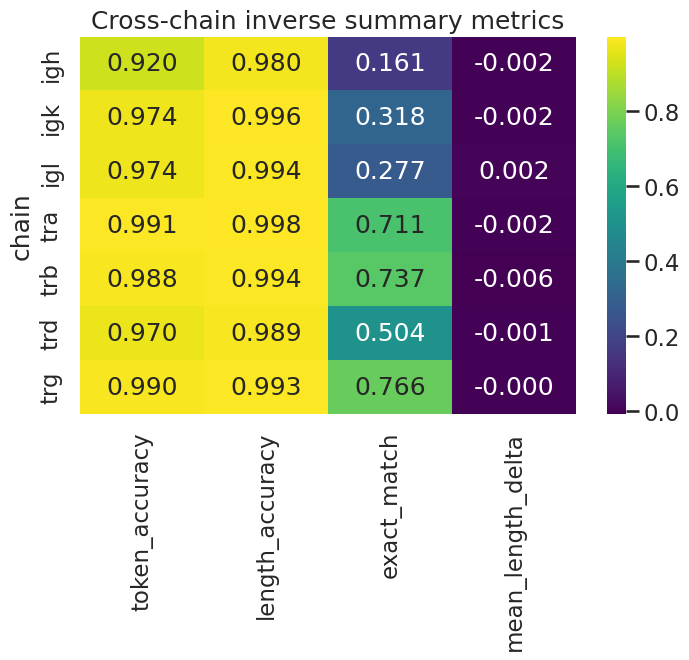

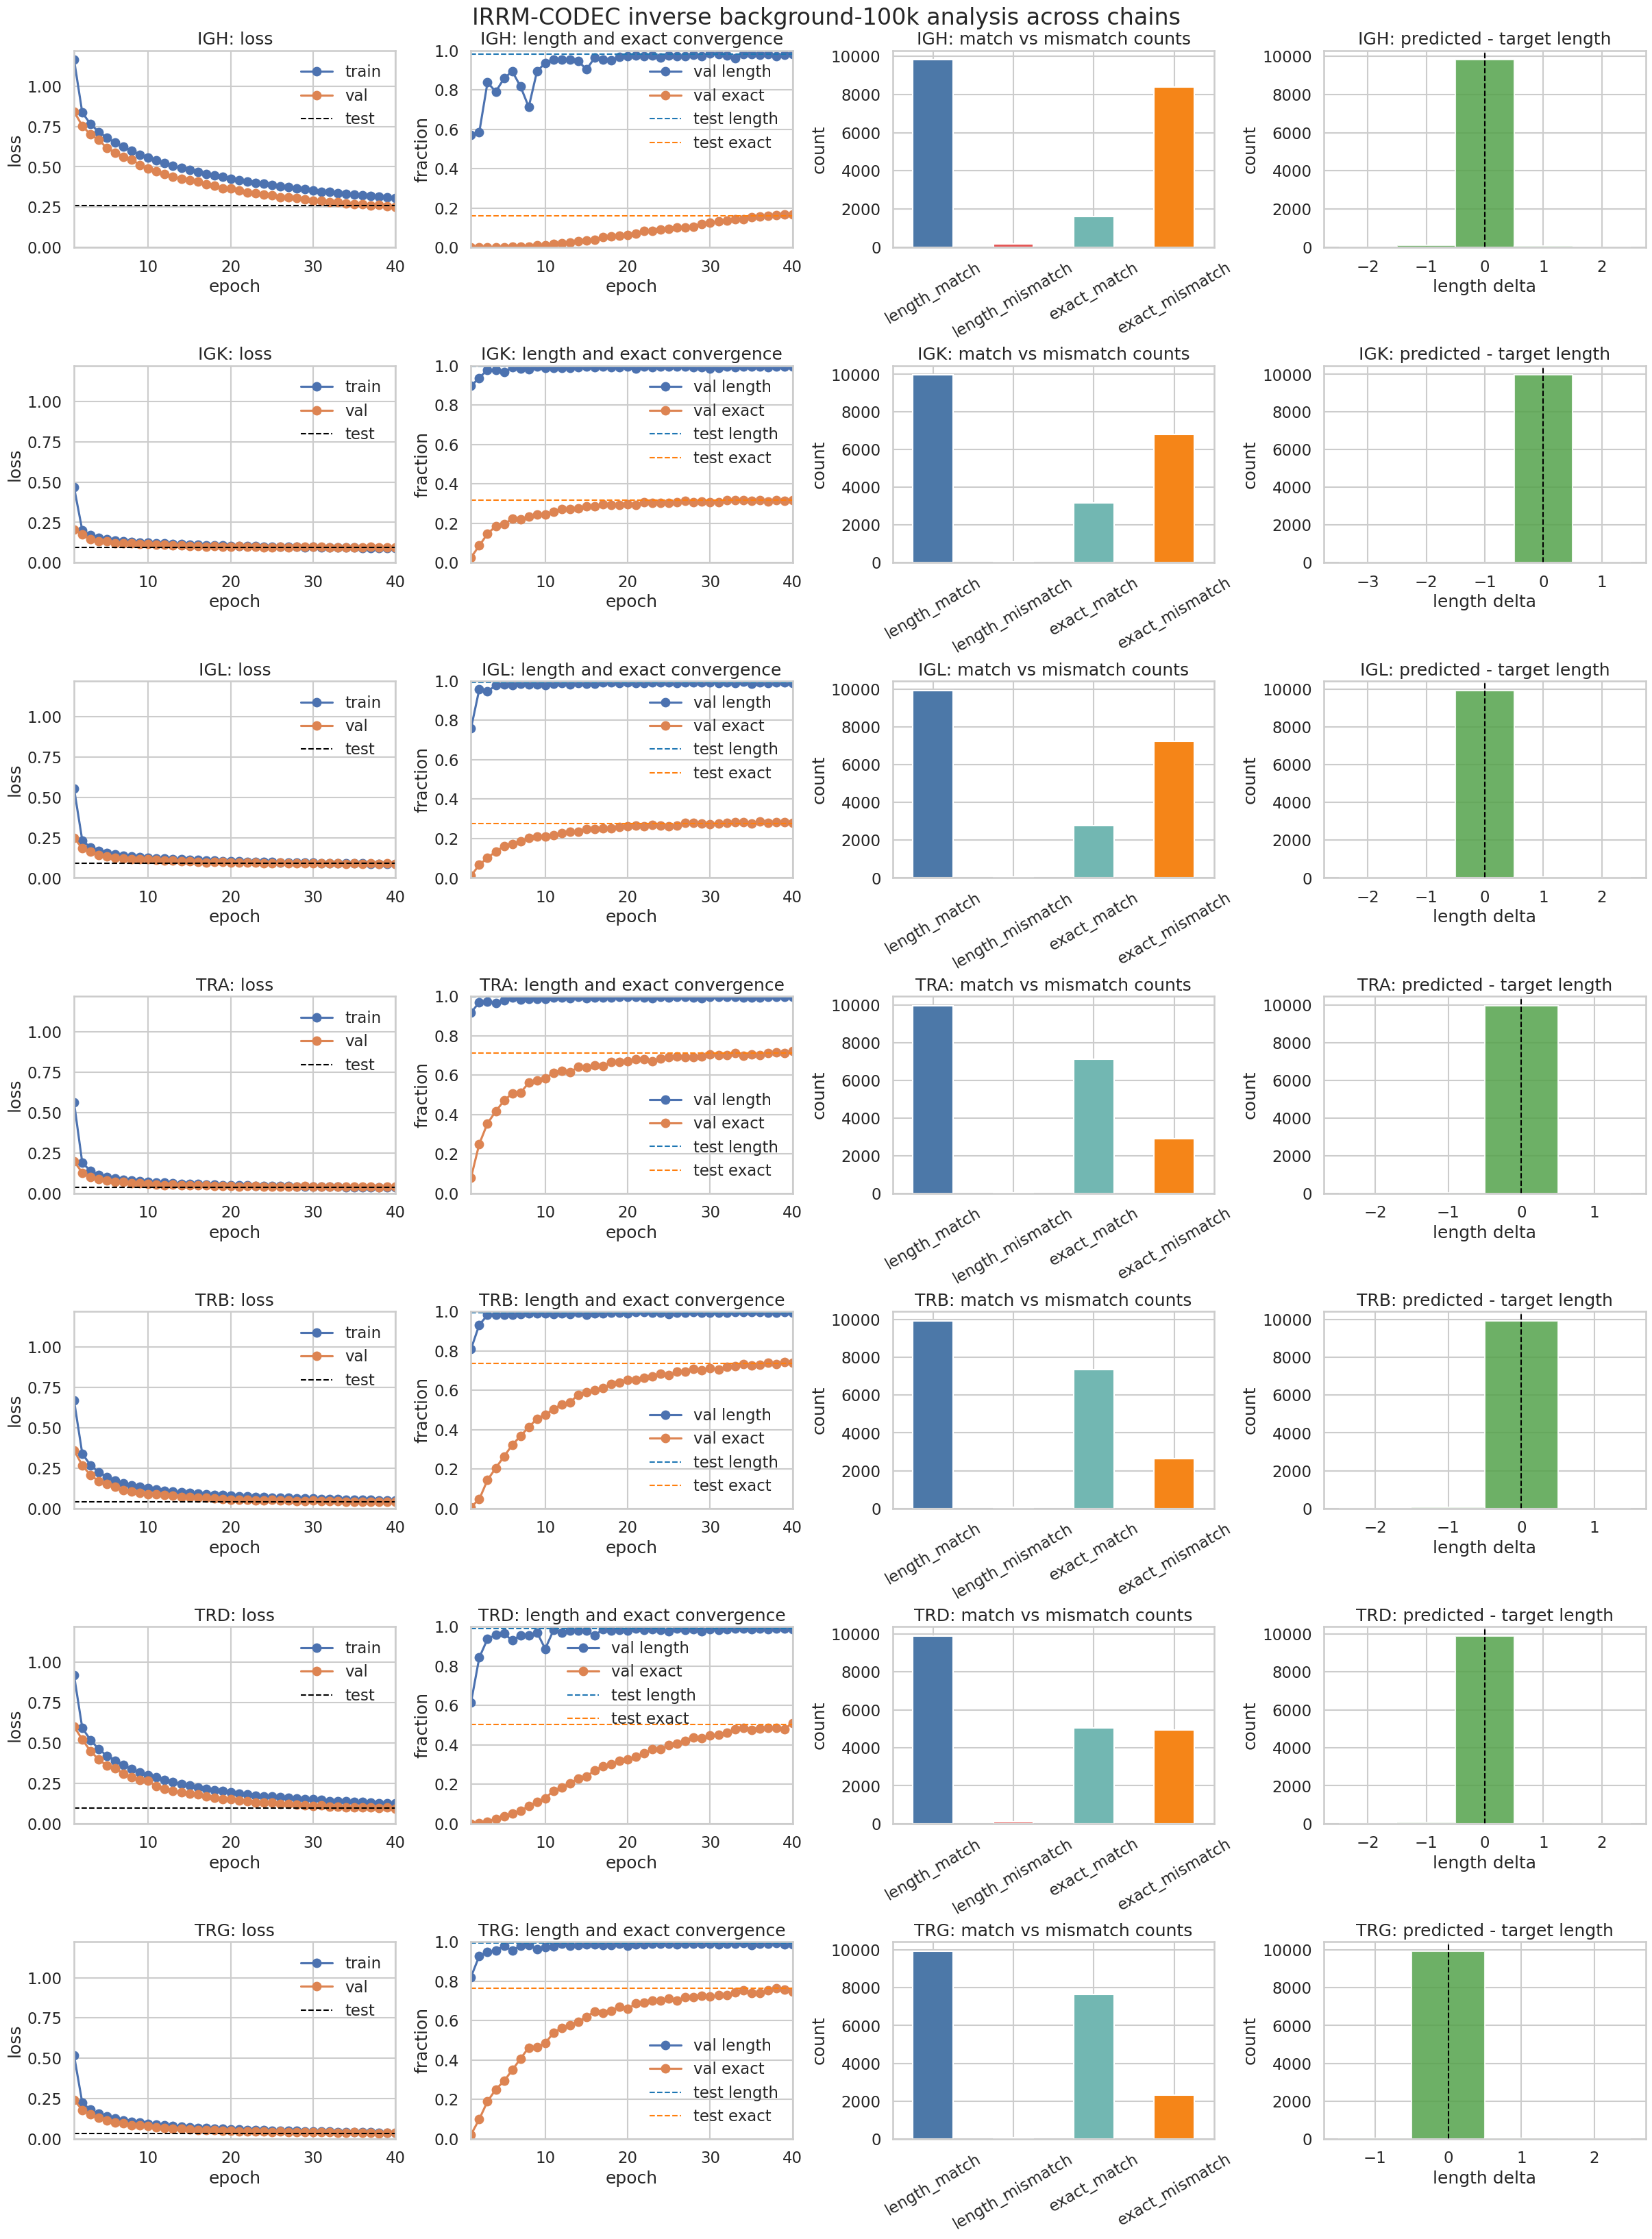

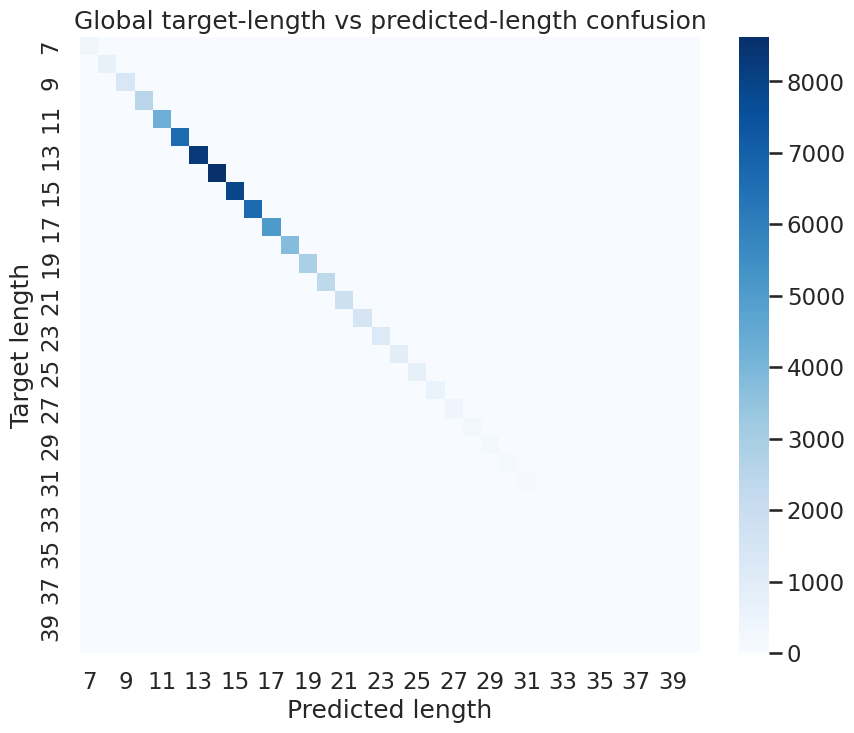

In [4]:
metric_heatmap = summary_df.set_index('chain')[[
    'token_accuracy',
    'length_accuracy',
    'exact_match',
    'mean_length_delta',
]].copy()

fig, ax = plt.subplots(figsize=(8, max(4, 0.7 * len(metric_heatmap))))
sns.heatmap(metric_heatmap, annot=True, fmt='.3f', cmap='viridis', ax=ax)
ax.set_title('Cross-chain inverse summary metrics')
plt.show()

all_histories = pd.concat(
    [result['history_df'].assign(chain=chain) for chain, result in results.items()],
    ignore_index=True,
)
all_result_rows = pd.concat([result['results_df'] for result in results.values()], ignore_index=True)
all_lengths = np.sort(np.unique(np.concatenate([
    result['results_df']['target_length'].unique() for result in results.values()
] + [
    result['results_df']['predicted_length'].unique() for result in results.values()
])))

global_epoch_max = int(all_histories['epoch'].max())
loss_min = min(all_histories['train.loss'].min(), all_histories['val.loss'].min(), summary_df['loss'].min())
loss_max = max(all_histories['train.loss'].max(), all_histories['val.loss'].max(), summary_df['loss'].max())
loss_pad = 0.05 * max(loss_max - loss_min, 1e-6)
loss_ylim = (max(0.0, loss_min - loss_pad), loss_max + loss_pad)

fig, axes = plt.subplots(len(results), 4, figsize=(24, 4.6 * len(results)), constrained_layout=True)
if len(results) == 1:
    axes = np.array([axes])

for row_idx, chain in enumerate(sorted(results)):
    result = results[chain]
    hist = result['history_df']
    res = result['results_df']
    test = result['recomputed_test_metrics']

    ax = axes[row_idx, 0]
    ax.plot(hist['epoch'], hist['train.loss'], marker='o', label='train')
    ax.plot(hist['epoch'], hist['val.loss'], marker='o', label='val')
    ax.axhline(test['loss'], color='black', linestyle='--', linewidth=1.5, label='test')
    ax.set_title(f'{chain.upper()}: loss')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.set_xlim(1, global_epoch_max)
    ax.set_ylim(*loss_ylim)
    ax.legend(frameon=False, loc='best')

    ax = axes[row_idx, 1]
    ax.plot(hist['epoch'], hist['val.length_accuracy'], marker='o', label='val length')
    ax.plot(hist['epoch'], hist['val.exact_match'], marker='o', label='val exact')
    ax.axhline(test['length_accuracy'], color='#1f77b4', linestyle='--', linewidth=1.5, label='test length')
    ax.axhline(test['exact_match'], color='#ff7f0e', linestyle='--', linewidth=1.5, label='test exact')
    ax.set_title(f'{chain.upper()}: length and exact convergence')
    ax.set_xlabel('epoch')
    ax.set_ylabel('fraction')
    ax.set_xlim(1, global_epoch_max)
    ax.set_ylim(0, 1)
    ax.legend(frameon=False, loc='best')

    ax = axes[row_idx, 2]
    counts = pd.Series({
        'length_match': int(res['length_match'].sum()),
        'length_mismatch': int((~res['length_match']).sum()),
        'exact_match': int(res['exact_match'].sum()),
        'exact_mismatch': int((~res['exact_match']).sum()),
    })
    counts.plot(kind='bar', ax=ax, color=['#4C78A8', '#E45756', '#72B7B2', '#F58518'])
    ax.set_title(f'{chain.upper()}: match vs mismatch counts')
    ax.set_xlabel('')
    ax.set_ylabel('count')
    ax.tick_params(axis='x', rotation=30)

    ax = axes[row_idx, 3]
    ax.hist(res['length_delta'], bins=np.arange(res['length_delta'].min(), res['length_delta'].max() + 2) - 0.5, color='#54A24B', alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
    ax.set_title(f'{chain.upper()}: predicted - target length')
    ax.set_xlabel('length delta')
    ax.set_ylabel('count')

fig.suptitle('IRRM-CODEC inverse background-100k analysis across chains', fontsize=24, y=1.01)
plt.show()

length_min = int(all_lengths.min())
length_max = int(all_lengths.max())
global_length_conf = pd.DataFrame(0, index=range(length_min, length_max + 1), columns=range(length_min, length_max + 1), dtype=int)
for result in results.values():
    conf = result['length_confusion']
    for idx in conf.index:
        for col in conf.columns:
            global_length_conf.loc[idx, col] += int(conf.loc[idx, col])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(global_length_conf, cmap='Blues', ax=ax)
ax.set_title('Global target-length vs predicted-length confusion')
ax.set_xlabel('Predicted length')
ax.set_ylabel('Target length')
plt.show()

In [ ]:
sub_rows = len(results)
fig, axes = plt.subplots(sub_rows, 2, figsize=(18, 7 * sub_rows), constrained_layout=True)
if sub_rows == 1:
    axes = np.array([axes])

global_substitution_matrix = pd.DataFrame(0, index=AA_ORDER, columns=AA_ORDER, dtype=int)
global_substitution_summary_rows = []

for row_idx, chain in enumerate(sorted(results)):
    result = results[chain]
    conf_mat = result['substitution_matrix']
    sub_summary = result['substitution_summary'].copy()
    sub_summary['chain'] = chain
    global_substitution_summary_rows.append(sub_summary.reset_index().rename(columns={'index': 'error_group'}))
    global_substitution_matrix = global_substitution_matrix.add(conf_mat, fill_value=0).astype(int)

    ax = axes[row_idx, 0]
    sns.heatmap(conf_mat, cmap='Greys', cbar=True, square=True, linewidths=0.5, linecolor='lightgray', ax=ax)
    for b in GROUP_BOUNDARIES:
        ax.hlines(b, 0, len(AA_ORDER), colors='black', linewidth=2)
        ax.vlines(b, 0, len(AA_ORDER), colors='black', linewidth=2)
    ax.set_title(f'{chain.upper()}: substitution confusion matrix')
    ax.set_xlabel('Predicted amino acid')
    ax.set_ylabel('Target amino acid')

    ax = axes[row_idx, 1]
    plot_df = result['substitution_summary'].reset_index().rename(columns={'index': 'error_group'})
    sns.barplot(data=plot_df, x='error_group', y='fraction', ax=ax, palette=['#4C78A8', '#E45756', '#72B7B2'])
    ax.set_ylim(0, 1)
    ax.set_title(f'{chain.upper()}: substitution error fractions')
    ax.set_xlabel('')
    ax.set_ylabel('fraction')
    ax.tick_params(axis='x', rotation=20)

plt.show()

global_substitution_summary = pd.concat(global_substitution_summary_rows, ignore_index=True)
display(global_substitution_summary)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(global_substitution_matrix, cmap='Greys', cbar=True, square=True, linewidths=0.5, linecolor='lightgray', ax=ax)
for b in GROUP_BOUNDARIES:
    ax.hlines(b, 0, len(AA_ORDER), colors='black', linewidth=2)
    ax.vlines(b, 0, len(AA_ORDER), colors='black', linewidth=2)
ax.set_title('Global substitution confusion matrix')
ax.set_xlabel('Predicted amino acid')
ax.set_ylabel('Target amino acid')
plt.show()

/scratch/ipykernel_3300542/2876859202.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='error_group', y='fraction', ax=ax, palette=['#4C78A8', '#E45756', '#72B7B2'])
/scratch/ipykernel_3300542/2876859202.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='error_group', y='fraction', ax=ax, palette=['#4C78A8', '#E45756', '#72B7B2'])
/scratch/ipykernel_3300542/2876859202.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='error_group', y='fraction', ax=ax, palette=['#4C78A8', '#E45756', '